# Confusion Matrix and Classification Report in Scikit-Learn
This notebook demonstrates how to evaluate a classification model using:

- Confusion Matrix
- Precision
- Recall
- F1 Score
- Classification Report

# Lets import our data

In [1]:
import pandas as pd
data = pd.read_csv("heart-disease.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [27]:
data = data.drop_duplicates()  #drop all duplicates in our data

In [28]:
import sklearn

# Check version
print(sklearn.__version__) #import sklearn and check version

1.7.1


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier #import our models

In [29]:
data["target"].unique() # array 1,0, we can understand that our target is a classification (this or that)

array([1, 0], dtype=int64)

In [6]:
X = data.drop("target", axis=1)
y = data["target"] #split our data into features and target

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) #split our features data (x) and target data(y) into train and test [80%, 20%]

In [8]:
clf = RandomForestClassifier(random_state=42) # call our model

In [9]:
clf.fit(x_train, y_train) # train our model on our train data

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
!pip install seaborn #install seaborn for visuals

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix #import seaborn and confusion_matrix

In [13]:
y_predict = clf.predict(x_test)
y_predict # our models prediction of y_test (y_predict)

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [14]:
confusion_matrix(y_test, y_predict) # check how confused our model was in predicting yes and No labels.

array([[26,  3],
       [ 5, 27]], dtype=int64)

In [15]:
cm = confusion_matrix(y_test, y_predict)

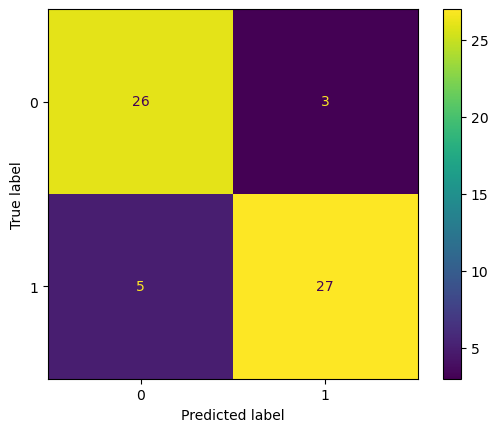

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay #plotting the confusion matrics right from sklearn library

ConfusionMatrixDisplay.from_predictions(y_test, y_predict); # looking at the confusion metrics, GOING FROM LEFT TO RIGHT, TN, FP, FN, TP

In [21]:
import matplotlib.pyplot as plt # import matplotlib to plot the confusion matrix in plt style.

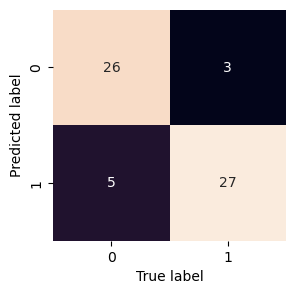

In [22]:
def plot_conf_mat(cm):
  """
  Plots a confusion matrix using Seaborn's heatmap().
  """
  fig, ax = plt.subplots(figsize=(3,3))
  ax = sns.heatmap(cm,
                    annot=True, # Annotate the boxes with cm info
                    cbar=False)
  plt.xlabel("True label")
  plt.ylabel("Predicted label")
plot_conf_mat(cm) #confusion matrix plotted with matplotlib 

In [31]:
from sklearn.metrics import classification_report
cr= classification_report(y_test, y_predict, output_dict= True) # import classification report and save it in a variable

In [33]:
cr_df = pd.DataFrame(cr).transpose()
cr_df.round(3) #print our classification report in datframe and rounded to 3 decimal places.

,precision,recall,f1-score,support
0,0.839,0.897,0.867,29.000
1,0.900,0.844,0.871,32.000
accuracy,0.869,0.869,0.869,0.869
macro avg,0.869,0.870,0.869,61.000
weighted avg,0.871,0.869,0.869,61.000


In [34]:
from sklearn.metrics import f1_score # import fi score from sk learn librbary

In [35]:
f1 = f1_score(y_test, y_predict)

print(f"F1 Score: {f1:.3f}") # find out the f1 score

F1 Score: 0.871
